In [1]:
import sys
import os

# 1. Add the build folder to Python's search path
sys.path.append(os.path.abspath("build/release"))

In [2]:
import specbridge as sb

In [3]:
n_clusters = 4

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Reproducible synthetic data from 4 clearly separated 2D clusters
rng = np.random.default_rng(42)
points_per_cluster = 5_000_000
cluster_std = 0.8
centers = np.array([
    [-6.0, -6.0],
    [ 6.0, -6.0],
    [-6.0,  6.0],
    [ 6.0,  6.0],
])

X_parts = []
for c in centers:
    X_parts.append(rng.normal(loc=c, scale=cluster_std, size=(points_per_cluster, 2)))

X = np.vstack(X_parts).astype(np.float32)

kmeans = sb.KMeans(n_clusters=n_clusters, random_state=42)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.cluster import KMeans as skKMeans

NUM_RUNS = 10

# --- WARMUP RUN ---
sb.set_num_threads(1)
kmeans.fit(X)

thread_counts = [1, 2, 4, 6, 8, 12, 24]
custom_times = []
custom_stds  = []

for n in thread_counts:
    sb.set_num_threads(n)

    times = []
    for _ in range(NUM_RUNS):
        t0 = time.perf_counter()
        kmeans.fit(X)
        times.append(time.perf_counter() - t0)

    custom_times.append(np.mean(times))
    custom_stds.append(np.std(times))

# --- SKLEARN ---
X = X.astype(np.float32)

sk = skKMeans(
    n_clusters=4,
    n_init=1,
    max_iter=20,
    algorithm='lloyd',
    init='k-means++',
    tol=0.0,
    random_state=42
)

sk.fit(X)  # warm-up

sk_times = []
for _ in range(NUM_RUNS):
    t0 = time.perf_counter()
    sk.fit(X)
    sk_times.append(time.perf_counter() - t0)

sklearn_time = np.mean(sk_times)
sklearn_std  = np.std(sk_times)

# --- METRICS ---
base = custom_times[0]
base_std = custom_stds[0]

speedups = [base / t for t in custom_times]

# Propagate std: s = base / t
speedup_stds = [
    s * np.sqrt((base_std/base)**2 + (t_std/t)**2)
    for s, t, t_std in zip(speedups, custom_times, custom_stds)
]

ideal = [t / thread_counts[0] for t in thread_counts]

efficiency = [s / t * 100 for s, t in zip(speedups, thread_counts)]

# Propagate std for efficiency
efficiency_stds = [
    (s_std / t) * 100
    for s_std, t in zip(speedup_stds, thread_counts)
]

x      = np.arange(len(thread_counts))
labels = [str(t) for t in thread_counts]



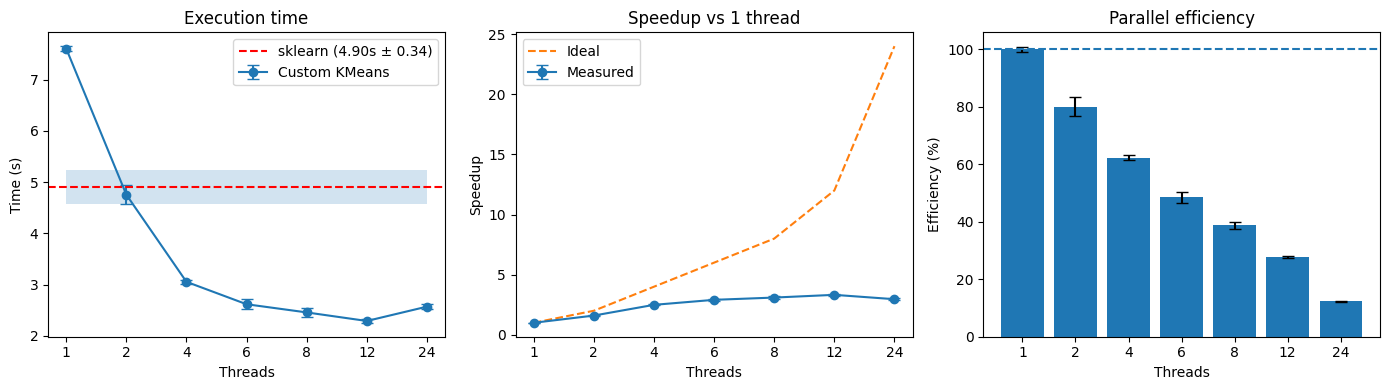

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Time ---
axes[0].errorbar(
    x, custom_times, yerr=custom_stds,
    fmt='o-', capsize=4, label='Custom KMeans'
)

# sklearn mean + std band
axes[0].axhline(
    sklearn_time, linestyle='--', color='red',
    label=f'sklearn ({sklearn_time:.2f}s ± {sklearn_std:.2f})'
)
axes[0].fill_between(
    x,
    np.full_like(x, sklearn_time - sklearn_std, dtype=float),
    np.full_like(x, sklearn_time + sklearn_std, dtype=float),
    alpha=0.2
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Execution time')
axes[0].legend()


# --- Speedup ---
axes[1].errorbar(
    x, speedups, yerr=speedup_stds,
    fmt='o-', capsize=4, label='Measured'
)
axes[1].plot(x, ideal, '--', label='Ideal')

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup vs 1 thread')
axes[1].legend()


# --- Efficiency ---
axes[2].bar(
    x, efficiency, yerr=efficiency_stds,
    capsize=4
)
axes[2].axhline(100, linestyle='--')

axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel('Threads')
axes[2].set_ylabel('Efficiency (%)')
axes[2].set_title('Parallel efficiency')


plt.tight_layout()
plt.savefig('kmeans_scaling.png')